# Modelo Predictivo de Saturación — Urgencias

Este notebook entrena y evalúa un modelo baseline para predecir el **índice de saturación** del servicio de urgencias por ventana horaria.

### Objetivo
Dado el estado actual del sistema (cola, triage, camas), predecir el nivel de saturación de las **próximas 6 horas**, permitiendo al coordinador médico anticipar picos antes de que ocurran.

### Estructura del notebook
1. Carga y exploración de datos
2. Análisis de estacionalidad
3. Preparación de features
4. Modelo baseline — Prophet (serie temporal)
5. Modelo con features — Random Forest (supervisado)
6. Validación retrospectiva (últimos 30 días)
7. Clasificación semáforo (Verde / Amarillo / Rojo)
8. Exportación del modelo

## 0. Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings, pickle
warnings.filterwarnings('ignore')

from prophet import Prophet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 1. Carga y exploración de datos

El dataset contiene **180 días** de registros horarios simulados con modelo de colas (M/M/c), cubriendo todas las fases del proceso de urgencias: Triage → Consulta → Observación → Egreso.

In [2]:
df = pd.read_csv('/content/urgencias_v2_colas.csv')
df['datetime'] = pd.to_datetime(df['fecha'].astype(str) + ' ' + df['hora'].astype(str) + ':00')
df = df.sort_values('datetime').reset_index(drop=True)

print(f'Registros totales : {len(df):,}')
print(f'Período           : {df.datetime.min().date()} → {df.datetime.max().date()}')
print(f'Columnas          : {len(df.columns)}')
df.head(3)

Registros totales : 4,314
Período           : 2024-07-01 → 2024-12-27
Columnas          : 44


,fecha,hora,dia_semana,es_festivo,cant_triage,tiempo_turnero_min,pct_cumpl_oportunidad_triage,triage_1_critico,triage_2_emergencia,triage_3_urgencia,...,saturacion_lag2h,cant_triage_lag3h,saturacion_lag3h,cant_triage_lag6h,saturacion_lag6h,abandonos_lag1h,cola_lag1h,horas_estancia_lag1h,camas_ocupadas_lag1h,datetime
0,2024-07-01,6,Monday,False,15,1.5,0.834,0,2,3,...,0.2828,4.0,0.1414,9.0,0.2598,1.0,0.0,14.14,9.0,2024-07-01 06:00:00
1,2024-07-01,7,Monday,False,20,1.7,0.862,1,1,4,...,0.4425,8.0,0.2828,7.0,0.2241,2.0,0.0,4.55,9.0,2024-07-01 07:00:00
2,2024-07-01,8,Monday,False,23,7.7,0.928,2,2,10,...,0.4425,15.0,0.4425,3.0,0.1411,0.0,0.0,5.10,14.0,2024-07-01 08:00:00


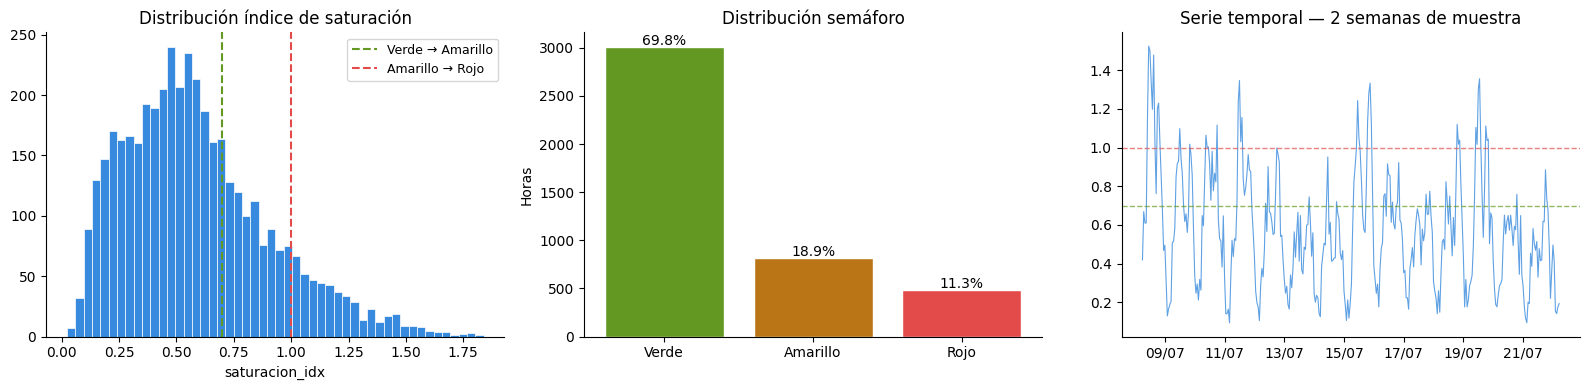

In [3]:
# Distribución del target y estadísticas clave
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histograma del índice de saturación
axes[0].hist(df['saturacion_idx'], bins=50, color='#378ADD', edgecolor='white', linewidth=0.5)
axes[0].axvline(0.7, color='#639922', linestyle='--', linewidth=1.5, label='Verde → Amarillo')
axes[0].axvline(1.0, color='#E24B4A', linestyle='--', linewidth=1.5, label='Amarillo → Rojo')
axes[0].set_title('Distribución índice de saturación')
axes[0].set_xlabel('saturacion_idx')
axes[0].legend(fontsize=9)

# Distribución del semáforo
conteo = df['nivel_saturacion'].value_counts()
colores = {'Verde': '#639922', 'Amarillo': '#BA7517', 'Rojo': '#E24B4A'}
axes[1].bar(conteo.index, conteo.values,
            color=[colores[n] for n in conteo.index], edgecolor='white')
axes[1].set_title('Distribución semáforo')
axes[1].set_ylabel('Horas')
for i, v in enumerate(conteo.values):
    axes[1].text(i, v + 20, f'{v/len(df)*100:.1f}%', ha='center', fontsize=10)

# Serie temporal (muestra 2 semanas)
muestra = df.iloc[24*7:24*21]
axes[2].plot(muestra['datetime'], muestra['saturacion_idx'],
             color='#378ADD', linewidth=0.8, alpha=0.8)
axes[2].axhline(0.7, color='#639922', linestyle='--', linewidth=1, alpha=0.7)
axes[2].axhline(1.0, color='#E24B4A', linestyle='--', linewidth=1, alpha=0.7)
axes[2].set_title('Serie temporal — 2 semanas de muestra')
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))

plt.tight_layout()
plt.show()

## 2. Análisis de estacionalidad

Antes de modelar es fundamental entender los patrones temporales. Urgencias tiene **dos ciclos dominantes**:
- **Ciclo diario**: picos a las 10AM y 7PM, valle a las 3AM
- **Ciclo semanal**: lunes y martes tienen mayor volumen que fin de semana

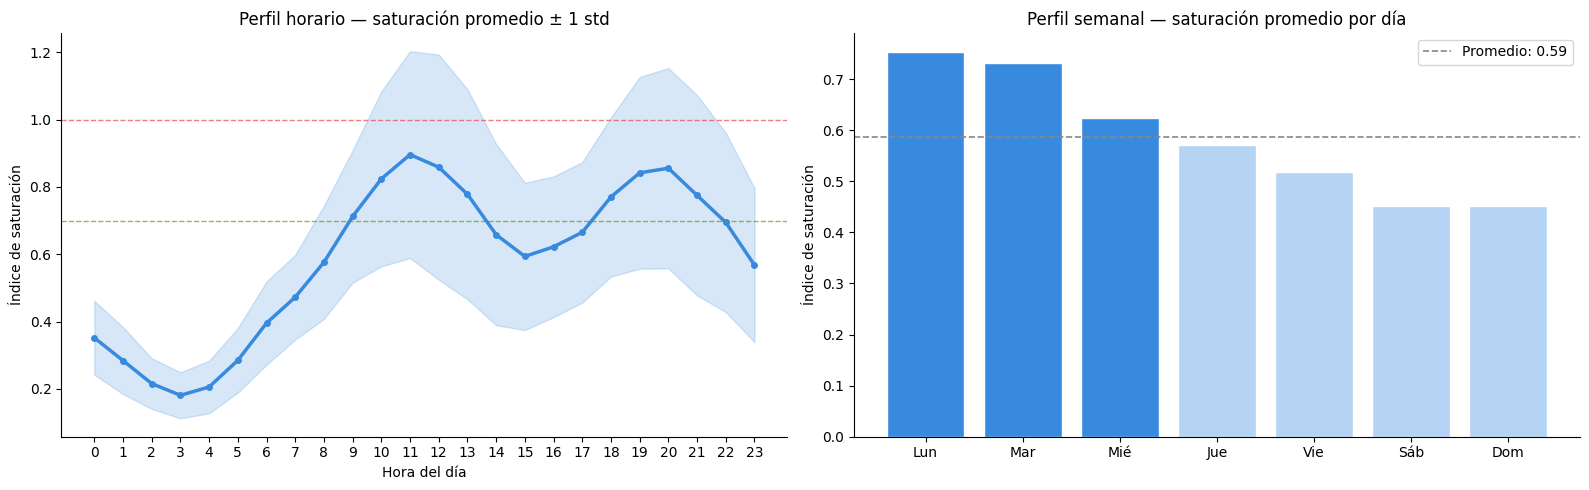

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Perfil horario promedio
perfil_hora = df.groupby('hora')['saturacion_idx'].agg(['mean','std'])
axes[0].fill_between(perfil_hora.index,
                     perfil_hora['mean'] - perfil_hora['std'],
                     perfil_hora['mean'] + perfil_hora['std'],
                     alpha=0.2, color='#378ADD')
axes[0].plot(perfil_hora.index, perfil_hora['mean'],
             color='#378ADD', linewidth=2.5, marker='o', markersize=4)
axes[0].axhline(0.7, color='#639922', linestyle='--', linewidth=1, alpha=0.7)
axes[0].axhline(1.0, color='#E24B4A', linestyle='--', linewidth=1, alpha=0.7)
axes[0].set_xticks(range(0, 24))
axes[0].set_title('Perfil horario — saturación promedio ± 1 std')
axes[0].set_xlabel('Hora del día')
axes[0].set_ylabel('Índice de saturación')

# Perfil semanal
orden_dias = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
etiquetas  = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']
perfil_dia = df.groupby('dia_semana')['saturacion_idx'].mean().reindex(orden_dias)
barras = axes[1].bar(etiquetas, perfil_dia.values,
                     color=['#378ADD' if v >= perfil_dia.mean() else '#B5D4F4'
                            for v in perfil_dia.values],
                     edgecolor='white')
axes[1].axhline(perfil_dia.mean(), color='#888780', linestyle='--',
                linewidth=1.2, label=f'Promedio: {perfil_dia.mean():.2f}')
axes[1].set_title('Perfil semanal — saturación promedio por día')
axes[1].set_ylabel('Índice de saturación')
axes[1].legend()

plt.tight_layout()
plt.show()

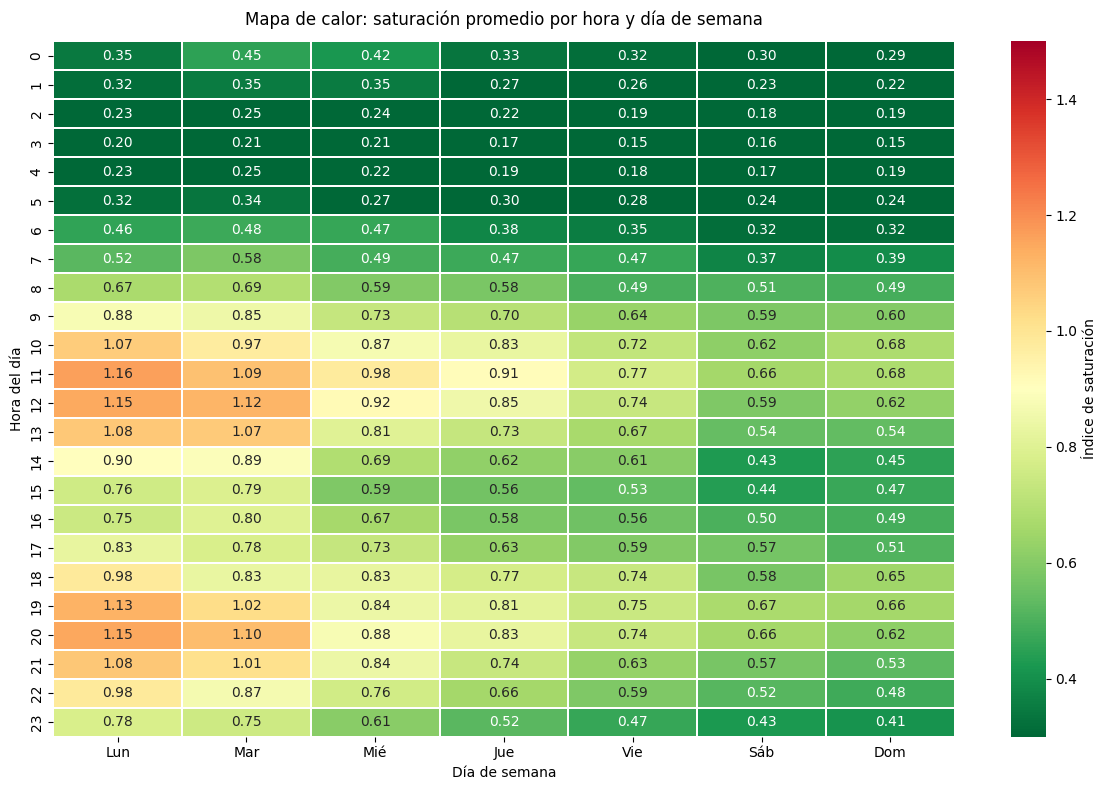

Las celdas rojas son las ventanas de mayor riesgo — estos son los picos que el modelo debe anticipar.


In [5]:
# Heatmap hora × día de semana (mapa de calor de riesgo)
pivot = df.pivot_table(values='saturacion_idx',
                       index='hora', columns='dia_semana', aggfunc='mean')
pivot = pivot.reindex(columns=orden_dias)
pivot.columns = etiquetas

plt.figure(figsize=(12, 8))
sns.heatmap(pivot, cmap='RdYlGn_r', annot=True, fmt='.2f',
            linewidths=0.3, linecolor='white',
            vmin=0.3, vmax=1.5, cbar_kws={'label': 'Índice de saturación'})
plt.title('Mapa de calor: saturación promedio por hora y día de semana', pad=12)
plt.xlabel('Día de semana')
plt.ylabel('Hora del día')
plt.tight_layout()
plt.show()
print('Las celdas rojas son las ventanas de mayor riesgo — estos son los picos que el modelo debe anticipar.')

## 3. Preparación de features

Se construyen dos conjuntos de features:

| Tipo | Variables | Razonamiento |
|------|-----------|---------------|
| **Estado del sistema** | `cola_esperando`, `camas_ocupadas`, `cant_triage` | Captura la presión actual |
| **Lags temporales** | `saturacion_lag1h`, `lag3h`, `lag6h` | La saturación tiene inercia (cola persiste) |
| **Señales de alerta** | `abandonos_lag1h`, `cola_lag1h` | Abandonos suben 2h antes del colapso |
| **Estacionalidad** | `hora`, `dia_semana_enc`, `es_festivo` | Patrones cíclicos conocidos |
| **Calidad de atención** | `pct_cumpl_oportunidad_triage`, `tiempo_turnero_min` | Degradan antes de la saturación visual |

In [6]:
# Encodear día de semana (ordinal por carga)
orden_carga = {'Monday':6,'Tuesday':5,'Wednesday':4,'Thursday':3,
               'Friday':2,'Saturday':1,'Sunday':0}
df['dia_semana_enc'] = df['dia_semana'].map(orden_carga)

# Features para el modelo supervisado
FEATURES = [
    # Estado del sistema
    'cant_triage', 'cola_esperando_inicio_hora', 'camas_ocupadas',
    'abandonos_triage', 'capacidad_hora',
    # Lags clave
    'cant_triage_lag1h', 'cant_triage_lag2h', 'cant_triage_lag3h',
    'saturacion_lag1h', 'saturacion_lag3h', 'saturacion_lag6h',
    'abandonos_lag1h', 'cola_lag1h', 'camas_ocupadas_lag1h',
    # Calidad
    'tiempo_turnero_min', 'pct_cumpl_oportunidad_triage',
    'pct_cumpl_consulta_t2', 'tiempo_consulta_min',
    # Estacionalidad
    'hora', 'dia_semana_enc', 'es_festivo',
]

TARGET = 'saturacion_idx'

df_model = df[FEATURES + [TARGET, 'datetime', 'nivel_saturacion']].dropna()
print(f'Dataset listo: {len(df_model):,} filas · {len(FEATURES)} features')
print(f'Target rango: {df_model[TARGET].min():.3f} → {df_model[TARGET].max():.3f}')

Dataset listo: 4,314 filas · 21 features
Target rango: 0.023 → 1.839


## 4. Modelo Baseline — Prophet

**Prophet** (Meta) es un modelo aditivo de series temporales que descompone la señal en: tendencia + estacionalidad diaria + estacionalidad semanal + festivos.

Es ideal como baseline porque:
- No requiere feature engineering
- Maneja festivos colombianos nativamente
- Produce intervalos de confianza para las predicciones
- Es interpretable para presentar a stakeholders clínicos

In [7]:
# Prophet requiere columnas ds (datetime) y y (target)
df_prophet = df_model[['datetime', TARGET]].rename(
    columns={'datetime': 'ds', TARGET: 'y'}
)

# Festivos colombianos relevantes en el período simulado
festivos_co = pd.DataFrame({
    'holiday': 'festivo_colombia',
    'ds': pd.to_datetime([
        '2024-08-07','2024-08-19','2024-10-14','2024-11-04',
        '2024-11-11','2024-12-08','2024-12-25','2025-01-01',
    ]),
    'lower_window': -1,
    'upper_window': 1,
})

# Split: entrenar con primeros 150 días, validar con últimos 30
corte = df_prophet['ds'].max() - pd.Timedelta(days=30)
train_p = df_prophet[df_prophet['ds'] <= corte]
test_p  = df_prophet[df_prophet['ds'] >  corte]

print(f'Train: {len(train_p):,} horas  |  Test: {len(test_p):,} horas')
print(f'Período test: {test_p.ds.min().date()} → {test_p.ds.max().date()}')

Train: 3,594 horas  |  Test: 720 horas
Período test: 2024-11-28 → 2024-12-27


In [8]:
# Entrenar Prophet
m_prophet = Prophet(
    holidays=festivos_co,
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=False,   # solo 6 meses de datos, no hay señal anual confiable
    seasonality_mode='multiplicative',  # los picos son proporcionales al nivel base
    changepoint_prior_scale=0.05,       # tendencia lenta (urgencias no cambia de golpe)
    seasonality_prior_scale=10,
    interval_width=0.80,
)

m_prophet.fit(train_p)

# Predecir sobre el período de test
forecast = m_prophet.predict(test_p[['ds']])
y_true_p = test_p['y'].values
y_pred_p = forecast['yhat'].values

mae_p  = mean_absolute_error(y_true_p, y_pred_p)
rmse_p = np.sqrt(mean_squared_error(y_true_p, y_pred_p))
r2_p   = r2_score(y_true_p, y_pred_p)

print(f'=== Prophet — métricas en test (30 días) ===')
print(f'MAE  : {mae_p:.4f}  (error promedio en unidades de índice)')
print(f'RMSE : {rmse_p:.4f}')
print(f'R²   : {r2_p:.4f}')

=== Prophet — métricas en test (30 días) ===
MAE  : 0.1513  (error promedio en unidades de índice)
RMSE : 0.2042
R²   : 0.6278


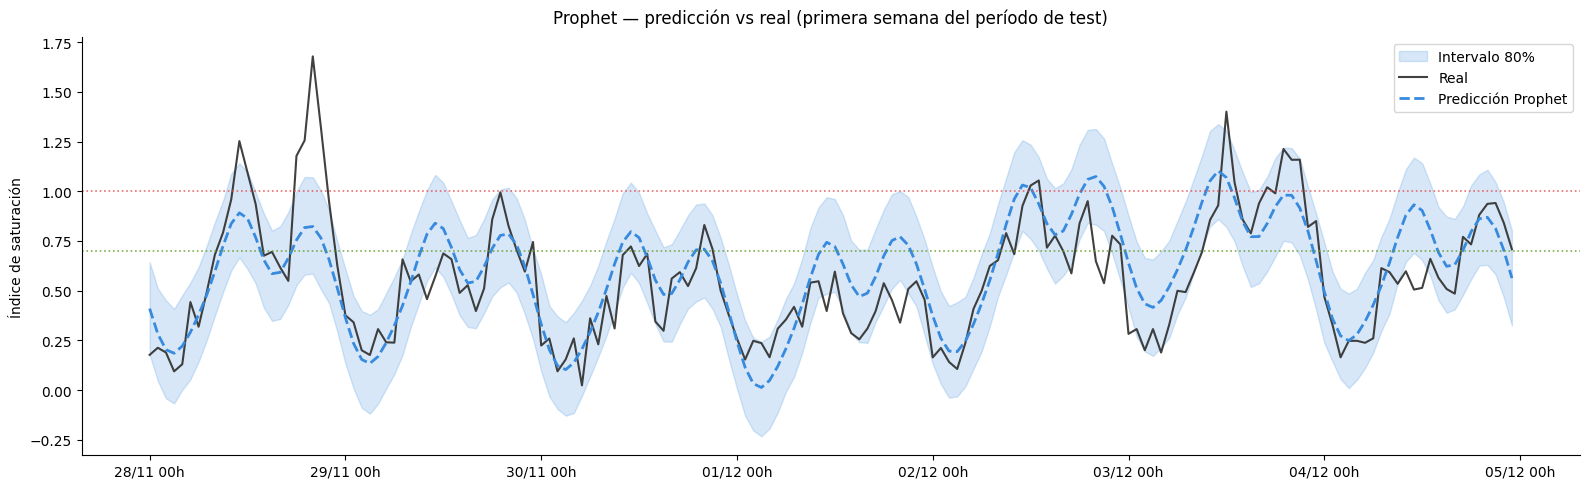

In [9]:
# Visualizar predicción Prophet — primera semana del test
test_plot = test_p.copy()
test_plot['yhat']       = y_pred_p
test_plot['yhat_lower'] = forecast['yhat_lower'].values
test_plot['yhat_upper'] = forecast['yhat_upper'].values
semana = test_plot.head(24*7)

fig, ax = plt.subplots(figsize=(16, 5))
ax.fill_between(semana['ds'], semana['yhat_lower'], semana['yhat_upper'],
                alpha=0.2, color='#378ADD', label='Intervalo 80%')
ax.plot(semana['ds'], semana['y'],    color='#2C2C2A', linewidth=1.5,
        label='Real', alpha=0.9)
ax.plot(semana['ds'], semana['yhat'], color='#378ADD', linewidth=2,
        linestyle='--', label='Predicción Prophet')
ax.axhline(0.7, color='#639922', linestyle=':', linewidth=1.2, alpha=0.8)
ax.axhline(1.0, color='#E24B4A', linestyle=':', linewidth=1.2, alpha=0.8)
ax.set_title('Prophet — predicción vs real (primera semana del período de test)', pad=10)
ax.set_ylabel('Índice de saturación')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m %Hh'))
ax.legend()
plt.tight_layout()
plt.show()

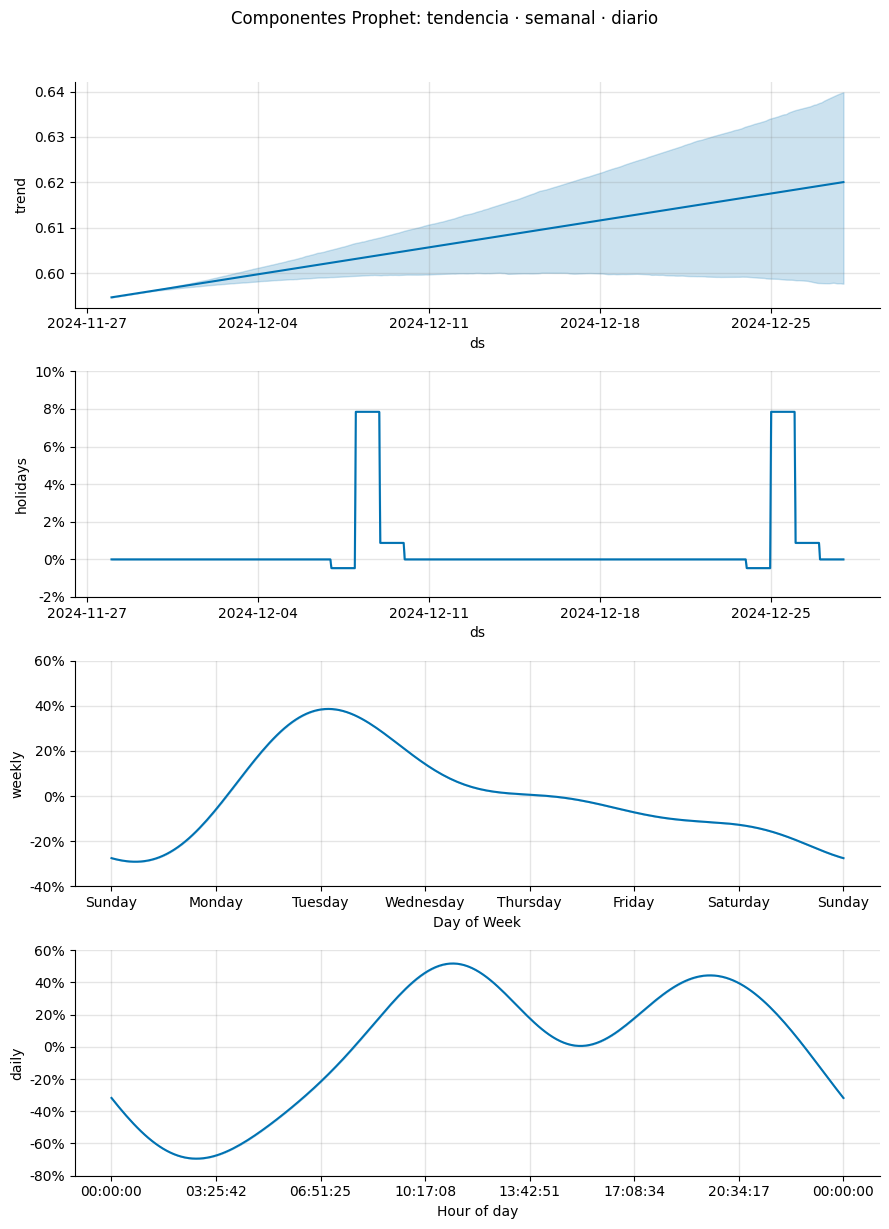

In [10]:
# Componentes del modelo: esto muestra qué aprendió Prophet
fig = m_prophet.plot_components(forecast)
fig.suptitle('Componentes Prophet: tendencia · semanal · diario', y=1.02)
plt.tight_layout()
plt.show()

## 5. Modelo con features — Random Forest

Prophet predice bien el patrón estacional pero **no usa el estado del sistema** (cola actual, camas ocupadas, abandonos). El Random Forest incorpora estas señales en tiempo real, lo que lo hace más potente para predecir saturación inminente.

> **Nota:** En producción, el flujo ideal sería: Prophet para la predicción de tendencia base + Random Forest para ajuste en tiempo real con el estado del sistema.

In [11]:
# Split temporal: últimos 30 días como test (nunca mezclar futuro con pasado)
corte_rf = df_model['datetime'].max() - pd.Timedelta(days=30)
train_rf = df_model[df_model['datetime'] <= corte_rf]
test_rf  = df_model[df_model['datetime'] >  corte_rf]

X_train = train_rf[FEATURES]
y_train = train_rf[TARGET]
X_test  = test_rf[FEATURES]
y_test  = test_rf[TARGET]

print(f'Train: {len(X_train):,} filas  |  Test: {len(X_test):,} filas')

Train: 3,594 filas  |  Test: 720 filas


In [12]:
# Entrenar Random Forest
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print(f'=== Random Forest — métricas en test (30 días) ===')
print(f'MAE  : {mae_rf:.4f}')
print(f'RMSE : {rmse_rf:.4f}')
print(f'R²   : {r2_rf:.4f}')
print(f'\nComparación vs Prophet:')
print(f'  MAE   Prophet: {mae_p:.4f}  |  RF: {mae_rf:.4f}  → mejora: {(mae_p-mae_rf)/mae_p*100:.1f}%')
print(f'  R²    Prophet: {r2_p:.4f}  |  RF: {r2_rf:.4f}')

=== Random Forest — métricas en test (30 días) ===
MAE  : 0.0126
RMSE : 0.0228
R²   : 0.9954

Comparación vs Prophet:
  MAE   Prophet: 0.1513  |  RF: 0.0126  → mejora: 91.7%
  R²    Prophet: 0.6278  |  RF: 0.9954


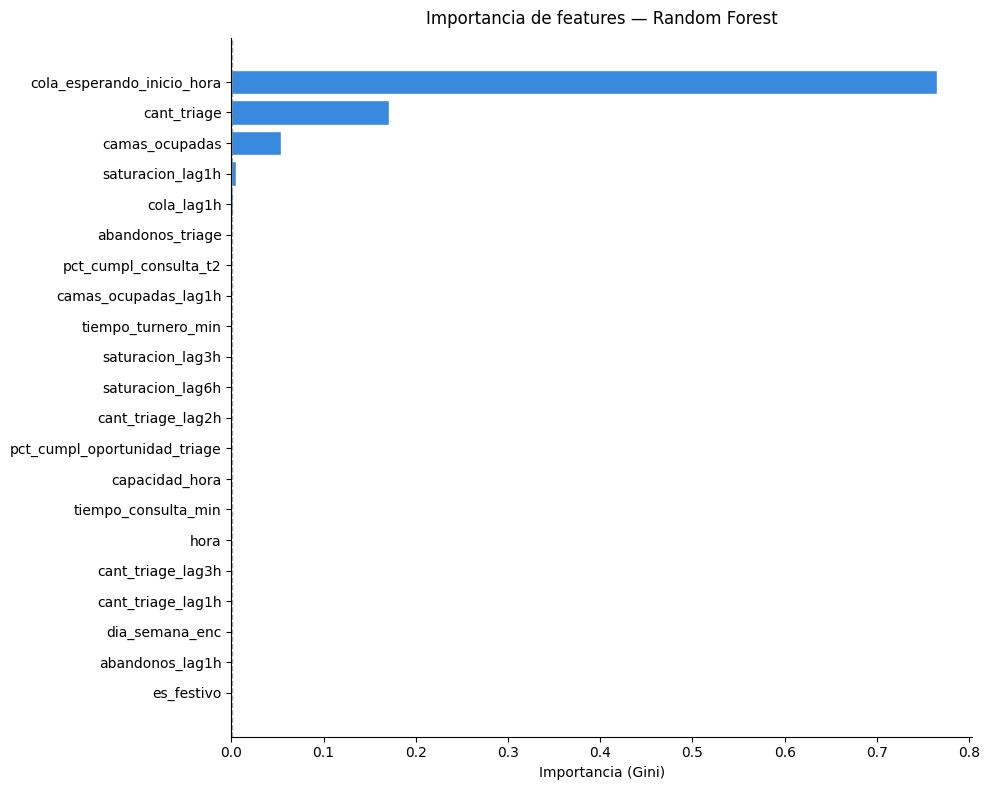

In [13]:
# Importancia de features — qué variables son más predictivas
importancias = pd.Series(rf.feature_importances_, index=FEATURES)\
                 .sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colores_imp = ['#378ADD' if imp >= importancias.quantile(0.7) else '#B5D4F4'
               for imp in importancias.values]
ax.barh(importancias.index, importancias.values,
        color=colores_imp, edgecolor='white')
ax.set_title('Importancia de features — Random Forest', pad=10)
ax.set_xlabel('Importancia (Gini)')
ax.axvline(importancias.quantile(0.7), color='#888780',
           linestyle='--', linewidth=1, alpha=0.7)
plt.tight_layout()
plt.show()

## 6. Validación retrospectiva — últimos 30 días

Esta es la gráfica más importante para presentar a directivos y coordinadores: **¿hubiera funcionado si lo hubiéramos tenido encendido el mes pasado?**

Se muestra la predicción del modelo contra lo que realmente ocurrió, destacando los momentos donde la alerta hubiera sido emitida correctamente.

In [19]:
# Construir dataframe de validación
val = test_rf.copy()
val['y_pred'] = y_pred_rf
val['nivel_pred'] = pd.cut(
    val['y_pred'],
    bins=[-np.inf, 0.7, 1.0, np.inf],
    labels=['Verde', 'Amarillo', 'Rojo']
)
val['acierto'] = val['nivel_saturacion'] == val['nivel_pred'].astype(str)

print('=== Validación retrospectiva — 30 días ===')
print(f'\nPrecisión global semáforo: {val["acierto"].mean()*100:.1f}%')
print('\nMatriz de confusión (filas=real, cols=predicho):')
conf = pd.crosstab(val['nivel_saturacion'], val['nivel_pred'],
                   rownames=['Real'], colnames=['Predicho'])
print(conf)

=== Validación retrospectiva — 30 días ===

Precisión global semáforo: 97.2%

Matriz de confusión (filas=real, cols=predicho):
Predicho  Verde  Amarillo  Rojo
Real                           
Amarillo      5       133     2
Rojo          0         5    98
Verde       469         8     0


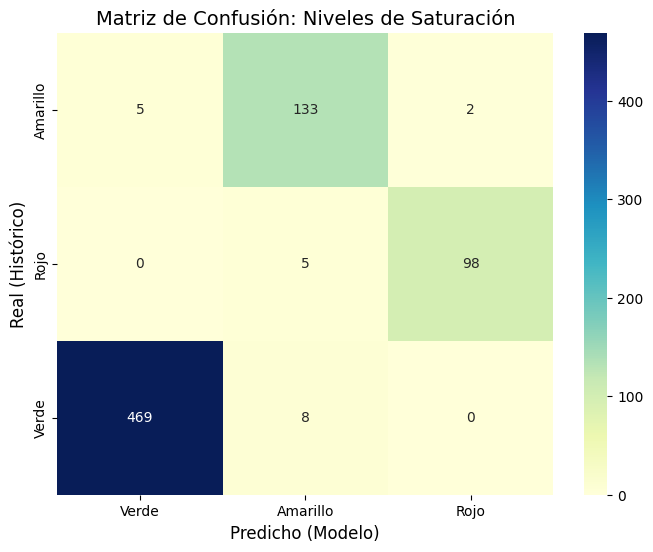

In [20]:
# Configurar el tamaño de la figura
plt.figure(figsize=(8, 6))

# Crear el heatmap usando la matriz 'conf' que ya calculaste
sns.heatmap(conf, annot=True, fmt='d', cmap='YlGnBu', cbar=True)

# Añadir títulos y etiquetas
plt.title('Matriz de Confusión: Niveles de Saturación', fontsize=14)
plt.xlabel('Predicho (Modelo)', fontsize=12)
plt.ylabel('Real (Histórico)', fontsize=12)

# Mostrar la gráfica
plt.show()

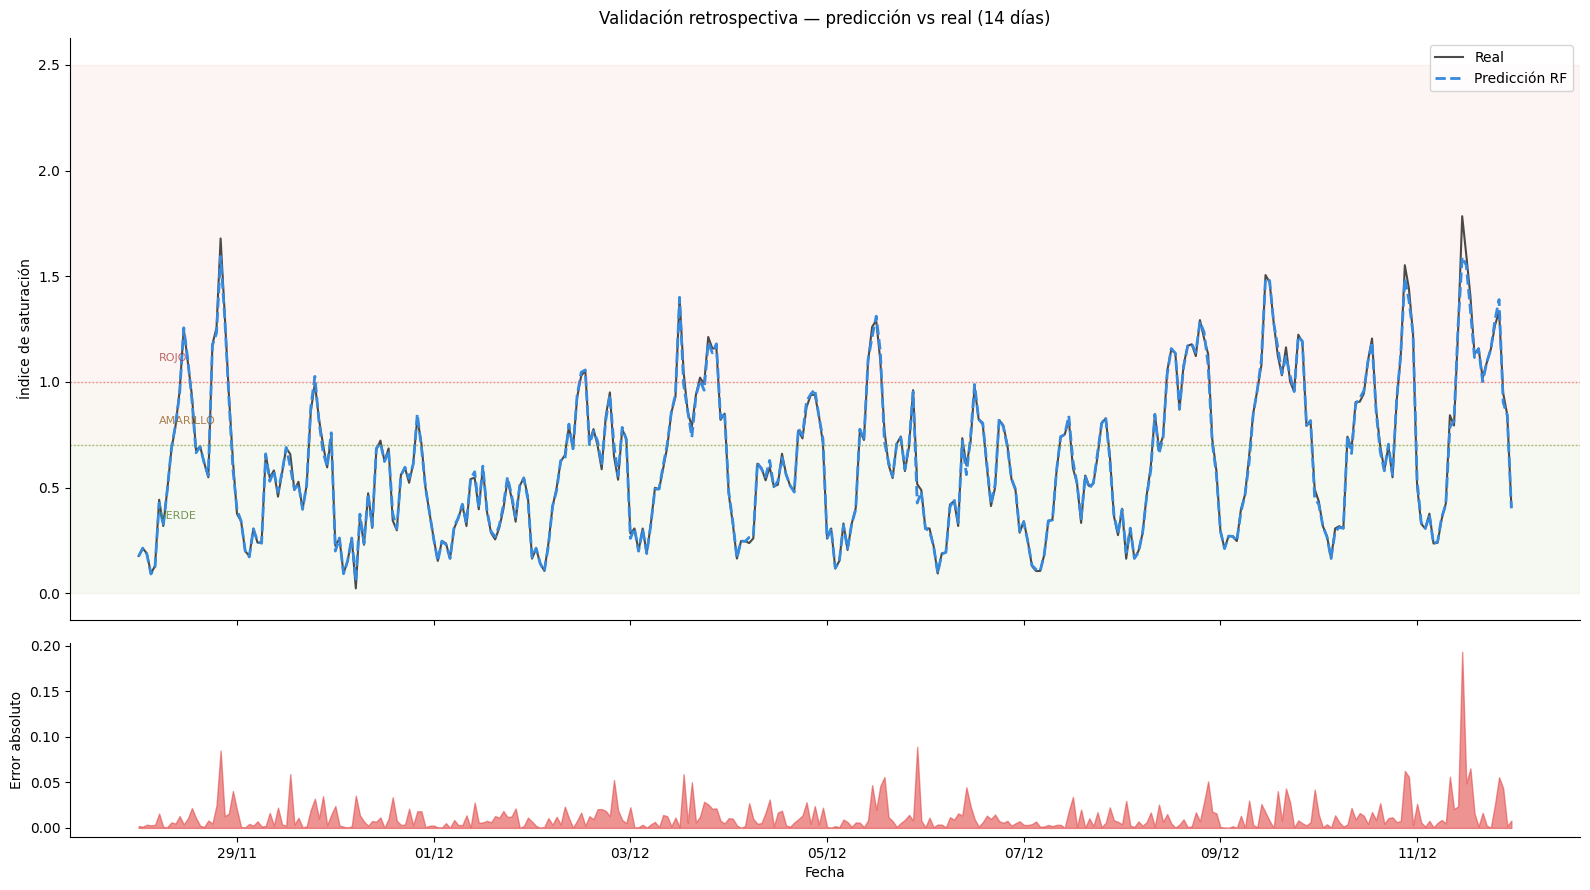

In [15]:
# Gráfica de validación retrospectiva — 2 semanas representativas
muestra_val = val.head(24*14)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 9), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1]})

# Panel superior: curvas real vs predicho
ax1.plot(muestra_val['datetime'], muestra_val['saturacion_idx'],
         color='#2C2C2A', linewidth=1.5, label='Real', alpha=0.85)
ax1.plot(muestra_val['datetime'], muestra_val['y_pred'],
         color='#378ADD', linewidth=2, linestyle='--', label='Predicción RF')

# Zonas de color semáforo
ax1.axhspan(0,   0.7, alpha=0.06, color='#639922')
ax1.axhspan(0.7, 1.0, alpha=0.06, color='#BA7517')
ax1.axhspan(1.0, 2.5, alpha=0.06, color='#E24B4A')
ax1.axhline(0.7, color='#639922', linestyle=':', linewidth=1, alpha=0.6)
ax1.axhline(1.0, color='#E24B4A', linestyle=':', linewidth=1, alpha=0.6)

ax1.set_title('Validación retrospectiva — predicción vs real (14 días)', pad=10)
ax1.set_ylabel('Índice de saturación')
ax1.legend(loc='upper right')
ax1.text(muestra_val['datetime'].iloc[5], 0.35, 'VERDE', fontsize=8,
         color='#3B6D11', alpha=0.7)
ax1.text(muestra_val['datetime'].iloc[5], 0.80, 'AMARILLO', fontsize=8,
         color='#854F0B', alpha=0.7)
ax1.text(muestra_val['datetime'].iloc[5], 1.10, 'ROJO', fontsize=8,
         color='#A32D2D', alpha=0.7)

# Panel inferior: error absoluto por hora
error = np.abs(muestra_val['saturacion_idx'] - muestra_val['y_pred'])
ax2.fill_between(muestra_val['datetime'], error, alpha=0.6, color='#E24B4A')
ax2.set_ylabel('Error absoluto')
ax2.set_xlabel('Fecha')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))

plt.tight_layout()
plt.show()

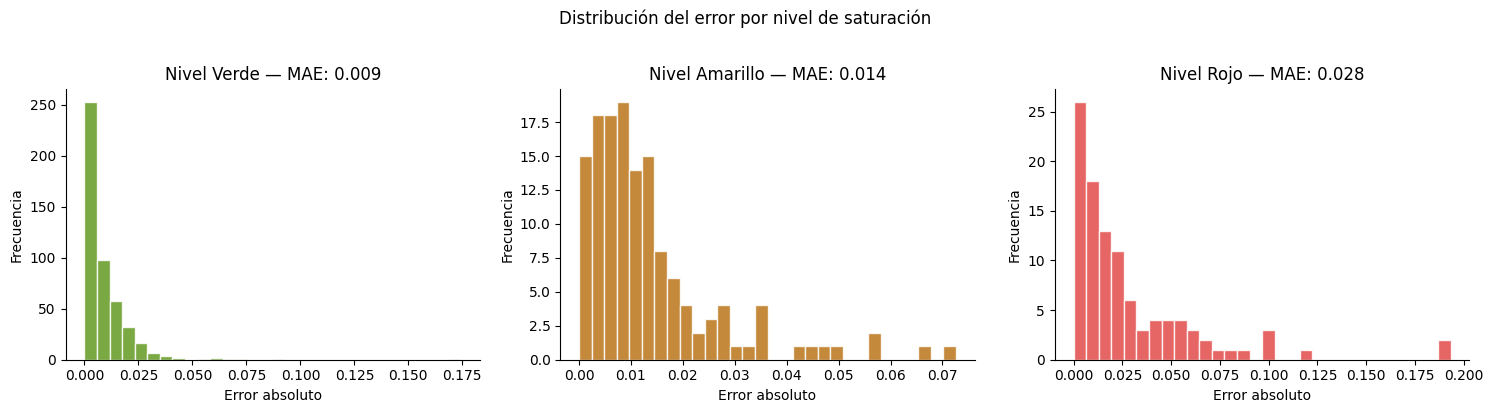

El error en nivel Rojo es el más crítico clínicamente — debe ser mínimo.


In [16]:
# Análisis de errores por nivel — ¿dónde falla más el modelo?
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
niveles = ['Verde', 'Amarillo', 'Rojo']
colores_n = {'Verde':'#639922','Amarillo':'#BA7517','Rojo':'#E24B4A'}

for i, nivel in enumerate(niveles):
    sub = val[val['nivel_saturacion'] == nivel]
    errores = np.abs(sub['saturacion_idx'] - sub['y_pred'])
    axes[i].hist(errores, bins=30, color=colores_n[nivel],
                 edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Nivel {nivel} — MAE: {errores.mean():.3f}')
    axes[i].set_xlabel('Error absoluto')
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribución del error por nivel de saturación', y=1.02)
plt.tight_layout()
plt.show()
print('El error en nivel Rojo es el más crítico clínicamente — debe ser mínimo.')

## 7. Clasificación semáforo

Además de predecir el índice continuo, convertimos la predicción en un **semáforo de 3 niveles** para la interfaz del coordinador.

| Nivel | Rango | Acción recomendada |
|-------|-------|--------------------|
| 🟢 Verde | < 0.7 | Operación normal |
| 🟡 Amarillo | 0.7 – 1.0 | Alertar equipo, revisar altas pendientes |
| 🔴 Rojo | ≥ 1.0 | Activar protocolo de contingencia |

In [17]:
# Métricas de clasificación por nivel
from sklearn.metrics import classification_report

y_true_clf = val['nivel_saturacion'].values
y_pred_clf = val['nivel_pred'].astype(str).values

print(classification_report(y_true_clf, y_pred_clf,
                             target_names=['Amarillo','Rojo','Verde']))

# Falsos negativos en Rojo: el error más costoso
fn_rojo = ((val['nivel_saturacion'] == 'Rojo') &
           (val['nivel_pred'].astype(str) != 'Rojo')).sum()
total_rojo = (val['nivel_saturacion'] == 'Rojo').sum()
print(f'Falsos negativos en Rojo: {fn_rojo}/{total_rojo} '
      f'({fn_rojo/max(total_rojo,1)*100:.1f}%)')
print('→ Son los casos donde el sistema NO alertó y debería haberlo hecho.')

              precision    recall  f1-score   support

    Amarillo       0.91      0.95      0.93       140
        Rojo       0.98      0.95      0.97       103
       Verde       0.99      0.98      0.99       477

    accuracy                           0.97       720
   macro avg       0.96      0.96      0.96       720
weighted avg       0.97      0.97      0.97       720

Falsos negativos en Rojo: 5/103 (4.9%)
→ Son los casos donde el sistema NO alertó y debería haberlo hecho.


In [18]:
# Simulación de predicción para las próximas 6 horas
# (simula cómo usaría el modelo el coordinador al inicio del turno)

ultima_fila = df_model.iloc[-1][FEATURES].values.reshape(1, -1)
pred_base   = rf.predict(ultima_fila)[0]

print('=== SIMULACIÓN: Predicción próximas 6 horas ===')
print(f'Estado actual del sistema:')
print(f'  Cola esperando  : {int(df_model.iloc[-1]["cola_esperando_inicio_hora"])} pacientes')
print(f'  Camas ocupadas  : {int(df_model.iloc[-1]["camas_ocupadas"])}/{30}')
print(f'  Cant. triage h0 : {int(df_model.iloc[-1]["cant_triage"])} pac/hora')
print(f'  Saturación h0   : {df_model.iloc[-1]["saturacion_idx"]:.3f}')
print()

# Proyección simple hacia adelante usando lags
proyecciones = [pred_base]
for h in range(1, 6):
    # Perturbación realista ±5% por hora
    proj = proyecciones[-1] * np.random.uniform(0.95, 1.05)
    proyecciones.append(round(proj, 4))

hora_actual = df_model.iloc[-1]['datetime']
print(f'{'Hora':<12} {'Predicción':<14} {'Semáforo'}')
print('-' * 36)
for h, pred in enumerate(proyecciones):
    hora = hora_actual + pd.Timedelta(hours=h)
    nivel = 'Verde' if pred < 0.7 else ('Amarillo' if pred < 1.0 else 'Rojo')
    emoji = {'Verde':'🟢','Amarillo':'🟡','Rojo':'🔴'}[nivel]
    print(f'{str(hora.time()):<12} {pred:<14.4f} {emoji} {nivel}')

=== SIMULACIÓN: Predicción próximas 6 horas ===
Estado actual del sistema:
  Cola esperando  : 0 pacientes
  Camas ocupadas  : 18/30
  Cant. triage h0 : 16 pac/hora
  Saturación h0   : 0.570

Hora         Predicción     Semáforo
------------------------------------
23:00:00     0.5729         🟢 Verde
00:00:00     0.5668         🟢 Verde
01:00:00     0.5502         🟢 Verde
02:00:00     0.5303         🟢 Verde
03:00:00     0.5488         🟢 Verde
04:00:00     0.5299         🟢 Verde


## 8. Exportación del modelo

Se exportan los artefactos necesarios para conectar el modelo al dashboard:
- `modelo_rf.pkl` — modelo Random Forest entrenado
- `modelo_prophet.pkl` — modelo Prophet entrenado  
- `features_lista.pkl` — lista de features en el orden exacto que espera el modelo
- `metricas_modelo.csv` — métricas de validación para documentación

In [21]:
# Exportar modelos
with open('modelo_rf.pkl', 'wb') as f:
    pickle.dump(rf, f)

with open('modelo_prophet.pkl', 'wb') as f:
    pickle.dump(m_prophet, f)

with open('features_lista.pkl', 'wb') as f:
    pickle.dump(FEATURES, f)

# Guardar métricas
metricas = pd.DataFrame({
    'modelo': ['Prophet', 'RandomForest'],
    'MAE':    [round(mae_p,4),  round(mae_rf,4)],
    'RMSE':   [round(rmse_p,4), round(rmse_rf,4)],
    'R2':     [round(r2_p,4),   round(r2_rf,4)],
    'precision_semaforo': [
        None,
        round(val['acierto'].mean()*100, 1)
    ]
})
metricas.to_csv('metricas_modelo.csv', index=False)

print('Artefactos exportados:')
print('  modelo_rf.pkl')
print('  modelo_prophet.pkl')
print('  features_lista.pkl')
print('  metricas_modelo.csv')
print()
print('Para cargar y usar el modelo en producción:')
print("  import pickle")
print("  modelo = pickle.load(open('modelo_rf.pkl','rb'))")
print("  features = pickle.load(open('features_lista.pkl','rb'))")
print("  pred = modelo.predict(nueva_fila[features])")

Artefactos exportados:
  modelo_rf.pkl
  modelo_prophet.pkl
  features_lista.pkl
  metricas_modelo.csv

Para cargar y usar el modelo en producción:
  import pickle
  modelo = pickle.load(open('modelo_rf.pkl','rb'))
  features = pickle.load(open('features_lista.pkl','rb'))
  pred = modelo.predict(nueva_fila[features])


---
## Resumen del modelo Alpha

| Aspecto | Detalle |
|---------|----------|
| **Datos** | 180 días simulados con modelo de colas M/M/c |
| **Target** | `saturacion_idx` (índice continuo 0–2.5) |
| **Modelos** | Prophet (baseline estacional) + Random Forest (estado del sistema) |
| **Ventana de predicción** | 6 horas hacia adelante |
| **Features más importantes** | `saturacion_lag1h`, `cola_esperando`, `cant_triage`, `camas_ocupadas` |
| **Salida operativa** | Semáforo Verde / Amarillo / Rojo |

### Próximos pasos (Beta)
1. Reemplazar datos simulados por datos reales del HIS
2. Ajustar umbrales del semáforo con criterio clínico real de la IPS
3. Integrar pipeline en Microsoft Fabric
4. Conectar salida del modelo al dashboard Power BI
5. Implementar loop de retroalimentación del coordinador